Name - Sandesh Arun Mohite

Roll No - 23

Division - T.Y(AIML)-A

**Train and save the model**

In [18]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
from mpl_toolkits.mplot3d import Axes3D

In [19]:
df = pd.read_csv("/content/drive/MyDrive/Cgpa_iq_package.csv")

In [20]:
df.shape

(200, 3)

In [21]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 3 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   cgpa     200 non-null    float64
 1   iq       200 non-null    int64  
 2   package  200 non-null    float64
dtypes: float64(2), int64(1)
memory usage: 4.8 KB


In [22]:
df.head()

,cgpa,iq,package
0,5.13,88,11.05
1,5.90,113,12.59
2,8.36,93,15.33
3,8.27,97,16.30
4,5.45,110,11.81


In [23]:
df.describe()

,cgpa,iq,package
count,200.000000,200.000000,200.000000
mean,6.983400,101.995000,13.439000
std,1.624101,12.161599,2.550027
min,4.600000,83.000000,8.490000
25%,5.407500,91.000000,11.135000
50%,7.040000,102.000000,13.600000
75%,8.585000,113.000000,15.542500
max,9.300000,121.000000,19.160000


In [24]:
#Define features (X) and target (y)
X = df[['cgpa', 'iq']]   # independent variables
y = df['package']        # dependent variable

In [25]:
#Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [26]:
#Train Linear Regression model
model = LinearRegression()
model.fit(X_train, y_train)

LinearRegression()

In [27]:
#Predictions
y_pred = model.predict(X_test)

In [28]:
#Evaluation
print("Coefficients (slopes):", model.coef_)
print("Intercept:", model.intercept_)
print("Mean Squared Error (MSE):", mean_squared_error(y_test, y_pred))
print("R² Score:", r2_score(y_test, y_pred))

Coefficients (slopes): [1.27307827 0.04407907]
Intercept: 0.026846398989246012
Mean Squared Error (MSE): 0.8021109840082266
R² Score: 0.8667649262834889


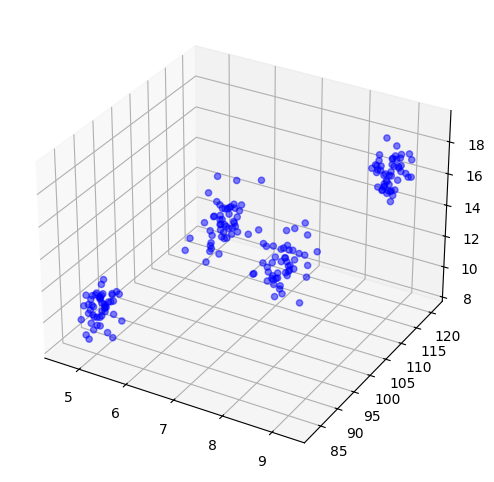

In [29]:
#Visualisation (3D Scatter + Regression Plane)
fig = plt.figure(figsize=(8,6))
ax = fig.add_subplot(111, projection='3d')

ax.scatter(X['cgpa'], X['iq'], y, c='blue', marker='o', alpha=0.5, label="Actual")

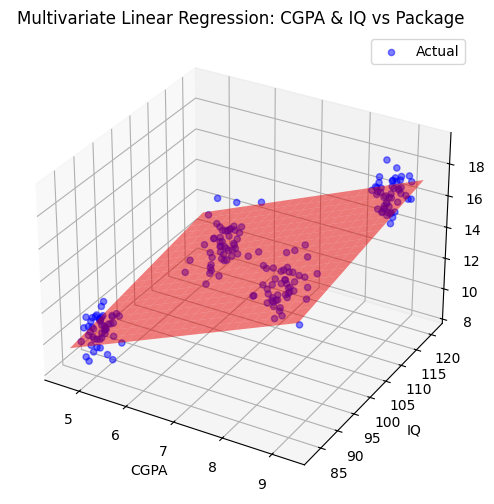

In [30]:
#Visualisation (3D Scatter + Regression Plane)
fig = plt.figure(figsize=(8,6))
ax = fig.add_subplot(111, projection='3d')

ax.scatter(X['cgpa'], X['iq'], y, c='blue', marker='o', alpha=0.5, label="Actual")

# Create meshgrid for regression plane
cgpa_range = np.linspace(X['cgpa'].min(), X['cgpa'].max(), 20)
iq_range = np.linspace(X['iq'].min(), X['iq'].max(), 20)
cgpa_grid, iq_grid = np.meshgrid(cgpa_range, iq_range)
package_pred = model.intercept_ + model.coef_[0]*cgpa_grid + model.coef_[1]*iq_grid

ax.plot_surface(cgpa_grid, iq_grid, package_pred, color='red', alpha=0.5)

ax.set_xlabel('CGPA')
ax.set_ylabel('IQ')
ax.set_zlabel('Package')
ax.set_title("Multivariate Linear Regression: CGPA & IQ vs Package")
plt.legend()
plt.show()

In [31]:
#Prediction for a new student
new_student = np.array([[8.5, 120]])  # example (cgpa=8.5, iq=120)
predicted_package = model.predict(new_student)
print("Predicted Package for CGPA=8.5 and IQ=120:", predicted_package[0])

Predicted Package for CGPA=8.5 and IQ=120: 16.13750021005186


/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


In [32]:
import pickle

In [33]:
pickle.dump(model,open('MLRModel.pkl','wb'))

**Flask Code**

In [34]:
from flask import Flask, render_template, request
import pickle
import numpy as np

app = Flask(__name__)

# Load the trained Multiple Linear Regression model
model = pickle.load(open("MLRModel.pkl", "rb"))


@app.route('/')
def home():
    return render_template("index.html")


@app.route('/predict', methods=['POST'])
def predict():

    # Read inputs from the HTML form
    cgpa = float(request.form['cgpa'])
    iq = float(request.form['iq'])

    # Predict package
    prediction = model.predict(np.array([[cgpa, iq]]))

    return render_template(
        "index.html",
        prediction_text=f"Predicted Package : {prediction[0]:.2f} LPA"
    )


if __name__ == "__main__":
    app.run(debug=True)

 * Serving Flask app '__main__'
 * Debug mode: on


INFO:werkzeug:WARNING: This is a development server. Do not use it in a production deployment. Use a production WSGI server instead.
 * Running on http://127.0.0.1:5000
INFO:werkzeug:Press CTRL+C to quit
INFO:werkzeug: * Restarting with watchdog (inotify)


**HTML Code**

In [35]:
<!DOCTYPE html>
<html lang="en">

<head>

    <meta charset="UTF-8">
    <meta name="viewport" content="width=device-width, initial-scale=1.0">

    <title>Student Package Predictor</title>

    <style>

        *{
            margin:0;
            padding:0;
            box-sizing:border-box;
            font-family:Arial, Helvetica, sans-serif;
        }

        body{

            background:#f4f7fc;
            display:flex;
            justify-content:center;
            align-items:center;
            height:100vh;

        }

        .container{

            width:430px;
            background:white;
            padding:35px;
            border-radius:15px;
            box-shadow:0 10px 25px rgba(0,0,0,.2);

        }

        h1{

            text-align:center;
            color:#0d47a1;
            margin-bottom:8px;

        }

        h3{

            text-align:center;
            color:#555;
            margin-bottom:25px;

        }

        label{

            font-weight:bold;
            display:block;
            margin-top:12px;
            margin-bottom:6px;

        }

        input{

            width:100%;
            padding:12px;
            border:1px solid #ccc;
            border-radius:8px;
            font-size:16px;

        }

        button{

            width:100%;
            margin-top:25px;
            padding:12px;
            font-size:18px;
            background:#1565c0;
            color:white;
            border:none;
            border-radius:8px;
            cursor:pointer;
            transition:.3s;

        }

        button:hover{

            background:#0d47a1;

        }

        .result{

            margin-top:25px;
            background:#e8f5e9;
            color:green;
            padding:15px;
            border-radius:8px;
            text-align:center;
            font-size:20px;
            font-weight:bold;

        }

        footer{

            text-align:center;
            margin-top:20px;
            color:#777;
            font-size:13px;

        }

    </style>

</head>

<body>

<div class="container">

    <h1>Student Package Predictor</h1>

    <h3>Multiple Linear Regression</h3>

    <form action="/predict" method="POST">

        <label>Enter Student CGPA</label>

        <input
            type="number"
            name="cgpa"
            step="0.01"
            min="0"
            max="10"
            placeholder="Example : 8.25"
            required>

        <label>Enter IQ Score</label>

        <input
            type="number"
            name="iq"
            placeholder="Example : 120"
            required>

        <button type="submit">

            Predict Package

        </button>

    </form>

    {% if prediction_text %}

    <div class="result">

        {{ prediction_text }}

    </div>

    {% endif %}

    <footer>

        Machine Learning by Dr. Sachin Balawant Takmare

    </footer>

</div>

</body>
</html>

SyntaxError: invalid decimal literal (2605738080.py, line 26)